In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/Wallet.csv')
print(df.head())
print(df.shape)

   wallet  male  business  punish  explain
0       2     0         0       2        0
1       2     0         0       2        1
2       3     0         0       1        1
3       3     0         0       2        0
4       1     1         0       1        1
(195, 5)


In [8]:
X = df.drop('wallet',axis=1)
y = df['wallet']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=6721
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 146
Test size: 49


In [18]:
def print_metrics(y_true, y_pred, set_name):
    print(f"\n--- {set_name} ---")
    print(f"Accuracy  = {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision (macro) = {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"Recall    (macro) = {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"F1        (macro) = {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")

def plot_confusion_matrix(y_true, y_pred, set_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {set_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

dtc = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=6721
)

dtc.fit(X_train, y_train)

y_prd_train = dtc.predict(X_train)
y_prd_test = dtc.predict(X_test)

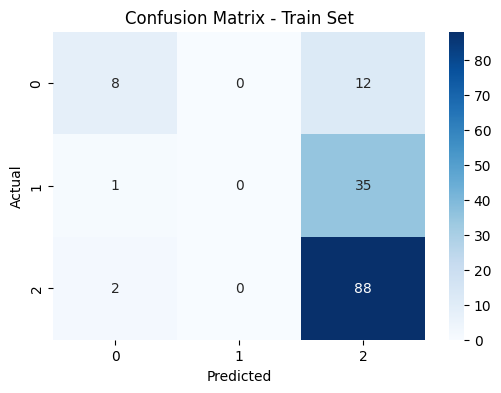

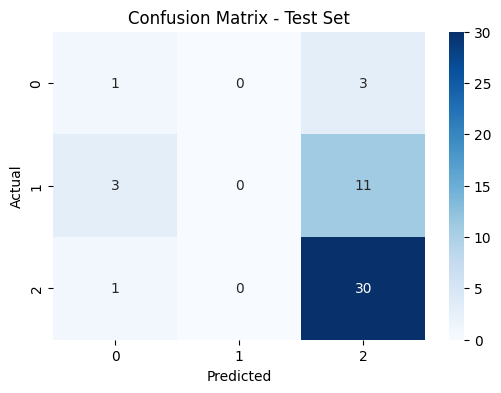


--- Train Set ---
Accuracy  = 0.6575
Precision (macro) = 0.4597
Recall    (macro) = 0.4593
F1        (macro) = 0.4328

--- Test Set ---
Accuracy  = 0.6327
Precision (macro) = 0.2939
Recall    (macro) = 0.4059
F1        (macro) = 0.3407


In [23]:
plot_confusion_matrix(y_train, y_prd_train, "Train Set")
plot_confusion_matrix(y_test, y_prd_test, "Test Set")

print_metrics(y_train, y_prd_train, "Train Set")
print_metrics(y_test, y_prd_test, "Test Set")